01 - Qualidade dos dados

Objetivo: Carregar todos os datasets do Olist e documentar a qualidade de cada um antes de qualquer análise.

Perguntas que este notebook responde: 
- Quantas linnhas e colunas tem cada tabela?
- Existem valores nulos? Em quais colunas?
- Existem linhas duplicadas?
- Os tipos de dados estão corretos?

In [1]:
""" Imports necessários """

import pandas as pd
import numpy as np
import missingno as msno
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.2f}'.format)

In [2]:
""" carregar todos os dados(CSVs) """

DATA_PATH = '../data/raw/'

orders    = pd.read_csv(DATA_PATH + 'olist_orders_dataset.csv')
items     = pd.read_csv(DATA_PATH + 'olist_order_items_dataset.csv')
payments  = pd.read_csv(DATA_PATH + 'olist_order_payments_dataset.csv')
reviews   = pd.read_csv(DATA_PATH + 'olist_order_reviews_dataset.csv')
customers = pd.read_csv(DATA_PATH + 'olist_customers_dataset.csv')
sellers   = pd.read_csv(DATA_PATH + 'olist_sellers_dataset.csv')
products  = pd.read_csv(DATA_PATH + 'olist_products_dataset.csv')
geo       = pd.read_csv(DATA_PATH + 'olist_geolocation_dataset.csv')
category  = pd.read_csv(DATA_PATH + 'product_category_name_translation.csv')

datasets = {
    'orders': orders,
    'items': items,
    'payments': payments,
    'reviews': reviews,
    'customers': customers,
    'sellers': sellers,
    'products': products,
    'geolocation': geo,
    'category_translation': category,
}

In [3]:
""" tabela geral """

summary = []

for name, df in datasets.items():
    summary.append({
        'dataset': name,
        'linhas': df.shape[0],
        'colunas': df.shape[1],
        'nulos_total': df.isnull().sum().sum(),
        'duplicatas': df.duplicated().sum(),
    })

pd.DataFrame(summary).set_index('dataset')

,linhas,colunas,nulos_total,duplicatas
dataset,,,,
orders,99441,8,4908,0
items,112650,7,0,0
payments,103886,5,0,0
reviews,99224,7,145903,0
customers,99441,5,0,0
sellers,3095,4,0,0
products,32951,9,2448,0
geolocation,1000163,5,0,261831
category_translation,71,2,0,0


In [5]:
""" inspecionar nulos por coluna(por dataset) """

for name, df in datasets.items():
    nulls = df.isnull().sum()
    nulls = nulls[nulls > 0]
    if len(nulls) > 0:
        print(f'\n── {name} ──')
        print(nulls.to_string())
    else:
        print(f'\n── {name} ── sem nulos')


── orders ──
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965

── items ── sem nulos

── payments ── sem nulos

── reviews ──
review_comment_title      87656
review_comment_message    58247

── customers ── sem nulos

── sellers ── sem nulos

── products ──
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2

── geolocation ── sem nulos

── category_translation ── sem nulos


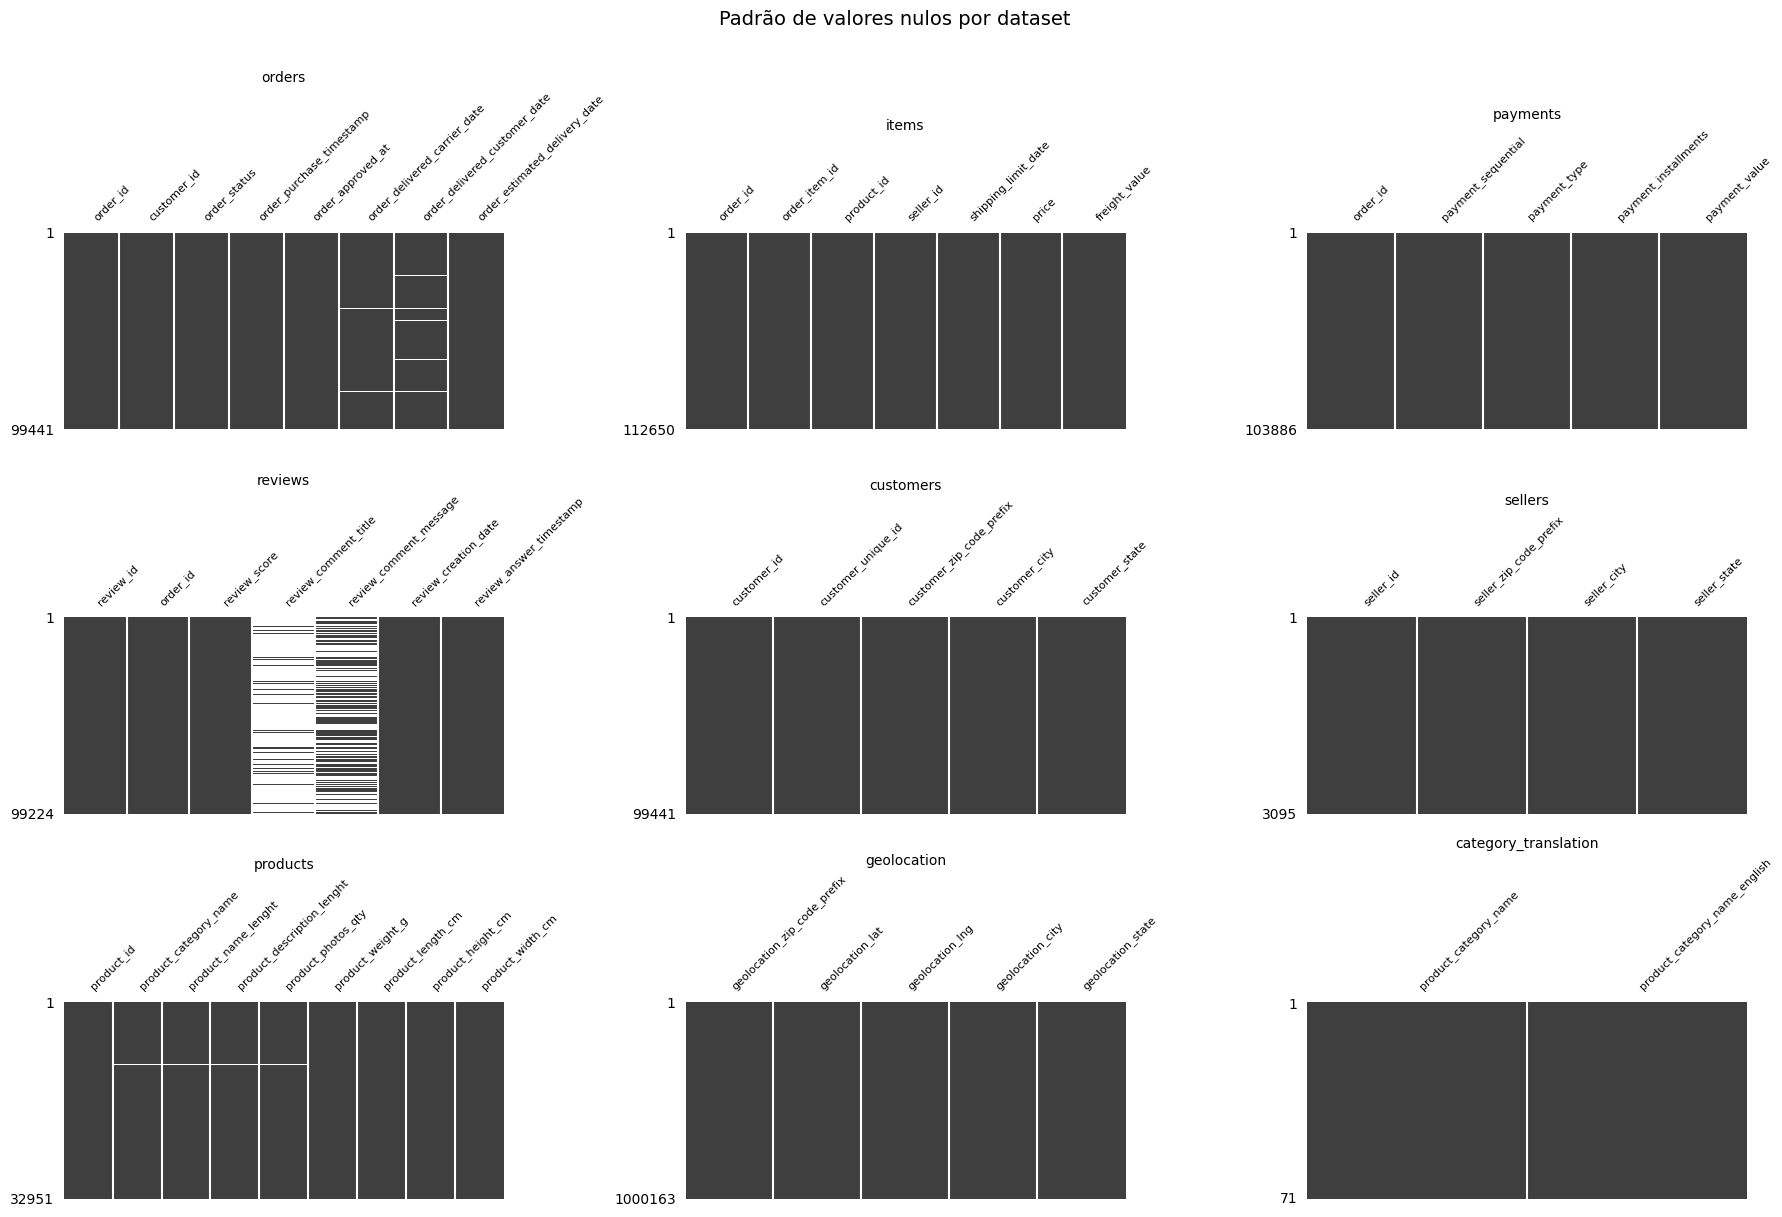

In [7]:
""" usar o missingno para visualizar padrões de nulos """

fig, axes = plt.subplots(3, 3, figsize=(18, 12))
axes = axes.flatten()

for i, (name, df) in enumerate(datasets.items()):
    msno.matrix(df, ax=axes[i], sparkline=False, fontsize=8)
    axes[i].set_title(name, fontsize=10)

plt.suptitle('Padrão de valores nulos por dataset', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/01_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
""" varificar tipos de colunas no dataset """

print('── orders ──')
print(orders.dtypes)
print('\n── items ──')
print(items.dtypes)

── orders ──
order_id                         object
customer_id                      object
order_status                     object
order_purchase_timestamp         object
order_approved_at                object
order_delivered_carrier_date     object
order_delivered_customer_date    object
order_estimated_delivery_date    object
dtype: object

── items ──
order_id                object
order_item_id            int64
product_id              object
seller_id               object
shipping_limit_date     object
price                  float64
freight_value          float64
dtype: object


## Conclusões

- `orders`: nulos nas colunas de data são esperados — pedidos cancelados
  ou não finalizados. Não exigem correção, mas devem ser filtrados
  nas análises de tempo de entrega.

- `reviews`: ~88k entradas sem título e ~58k sem comentário. Campos
  opcionais — serão ignorados nas análises de satisfação.

- `products`: 610 produtos com cadastro incompleto. Serão excluídos
  nas análises de categoria. 2 produtos sem peso/dimensão — impacto
  mínimo.

- `geolocation`: 261.831 duplicatas por design — um CEP pode ter
  várias coordenadas. Aplicar `drop_duplicates('geolocation_zip_code_prefix')`
  antes de qualquer merge.

- Colunas de data em `orders` estão como `object` — converter com
  `pd.to_datetime()` no próximo notebook.